In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

In [29]:
%config InlineBackend.figure_format = 'svg'

In [30]:
df_r2 = pd.DataFrame({'Density': [0.7757, 0.8180, 0.8201],
                      'Detonation Velocity': [0.9523, 0.9155, 0.9568],
                      'Explosion Capacity': [0.5698, 0.2882, 0.6743],
                      'Explosion Heat': [0.8620, 0.6688, 0.8395],
                      'Explosion Pressure': [0.9420, 0.9342, 0.9525],
                      'Solid Phase Formation Enthalpy': [0.7940, 0.5943, 0.7658]},
                     index=['Kernel Ridge', 'SVR', 'Random Forest'])

In [31]:
df_r2 = pd.DataFrame({'Density': [0.7757, 0.8180, 0.8201],
                      'Detonation Velocity': [0.9523, 0.9155, 0.9568],
                      'Explosion Capacity': [0.5698, 0.2882, 0.6743],
                      'Explosion Heat': [0.8620, 0.6688, 0.8395],
                      'Explosion Pressure': [0.9420, 0.9342, 0.9525]},
                     index=['Kernel Ridge', 'SVR', 'Random Forest'])

In [32]:
df_r2

,Density,Detonation Velocity,Explosion Capacity,Explosion Heat,Explosion Pressure
Kernel Ridge,0.7757,0.9523,0.5698,0.8620,0.9420
SVR,0.8180,0.9155,0.2882,0.6688,0.9342
Random Forest,0.8201,0.9568,0.6743,0.8395,0.9525


In [33]:
df_r2 = df_r2.melt(ignore_index=False)

In [34]:
df_r2

,variable,value
Kernel Ridge,Density,0.7757
SVR,Density,0.8180
Random Forest,Density,0.8201
Kernel Ridge,Detonation Velocity,0.9523
SVR,Detonation Velocity,0.9155
Random Forest,Detonation Velocity,0.9568
Kernel Ridge,Explosion Capacity,0.5698
SVR,Explosion Capacity,0.2882
Random Forest,Explosion Capacity,0.6743
Kernel Ridge,Explosion Heat,0.8620


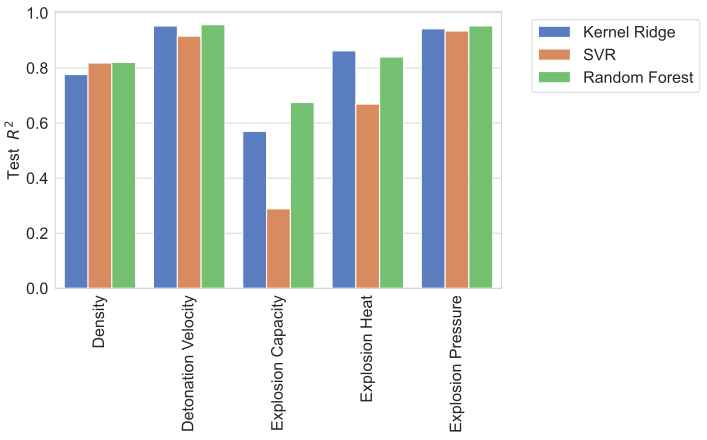

In [36]:
plt.rcParams.update({'font.size':16})
plt.figure(figsize=(8,5))
sns.set_style('whitegrid')
sns.set_palette('muted')
sns.barplot(x='variable', y='value', hue=df_r2.index, data=df_r2)
plt.xticks(rotation=90)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel('')
plt.ylabel('Test  $R^2$')
plt.show()

In [37]:
df_rrmse = pd.DataFrame({'Density': [4.01,3.62,3.59],
                         'Detonation\nVelocity': [4.35,5.78,4.14],
                         'Explosion\nCapacity': [11.13,14.32,9.68],
                         'Explosion\nHeat': [14.71,22.65,15.77],
                         'Explosion\nPressure': [10.08,10.73,9.12],
                         'Solid Phase\nFormation\nEnthalpy': [76.74,107.68,81.83]},
                        index=['Kernel Ridge', 'SVR', 'Random Forest'])

In [42]:
df_rrmse = pd.DataFrame({'Density': [4.01,3.62,3.59,3.94],
                         'Detonation\nVelocity': [4.35,5.78,4.14,4.43],
                         'Explosion\nCapacity': [11.13,14.32,9.68,8.76],
                         'Explosion\nHeat': [14.71,22.65,15.77,13.74],
                         'Explosion\nPressure': [10.08,10.73,9.12,10.45]},
                        index=['Kernel Ridge', 'SVR', 'Random Forest', 'XGBoost'])

In [43]:
df_rrmse = df_rrmse.melt(ignore_index=False)

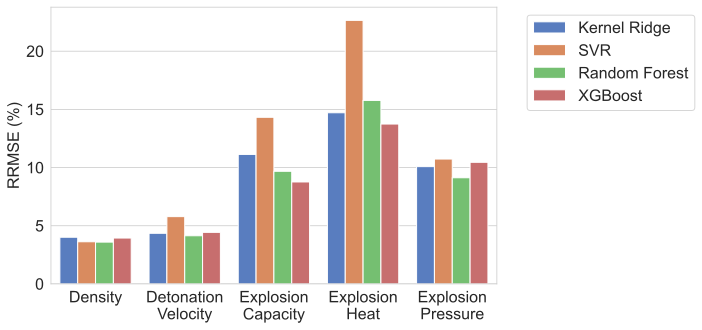

In [44]:
plt.figure(figsize=(8,5))
sns.set_style('whitegrid')
sns.set_palette('muted')
sns.barplot(x='variable', y='value', hue=df_rrmse.index, data=df_rrmse)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel('')
plt.ylabel('RRMSE (%)')
plt.show()

In [45]:
df_rrmse.loc['Random Forest']['value'].mean()

np.float64(8.459999999999999)

In [46]:
df_rrmse.loc['SVR']['value'].mean()

np.float64(11.419999999999998)

In [47]:
df_rrmse.loc['Kernel Ridge']['value'].mean()

np.float64(8.856)

In [48]:
df_rrmse.loc['XGBoost']['value'].mean()

np.float64(8.264)

## Precision@k

$P@k=\frac{1}{k}\sum_{i=1}^k rel_i$

In [57]:
df_rag = pd.read_csv('Precision_at_k.csv')

In [58]:
df_rag = df_rag[df_rag['Error'].isna()]

In [59]:
df_rag_mod = df_rag.filter(regex='Precision|Field').groupby(by='Field', as_index=False).mean()

In [60]:
df_rag_mod = df_rag_mod.melt(id_vars='Field')

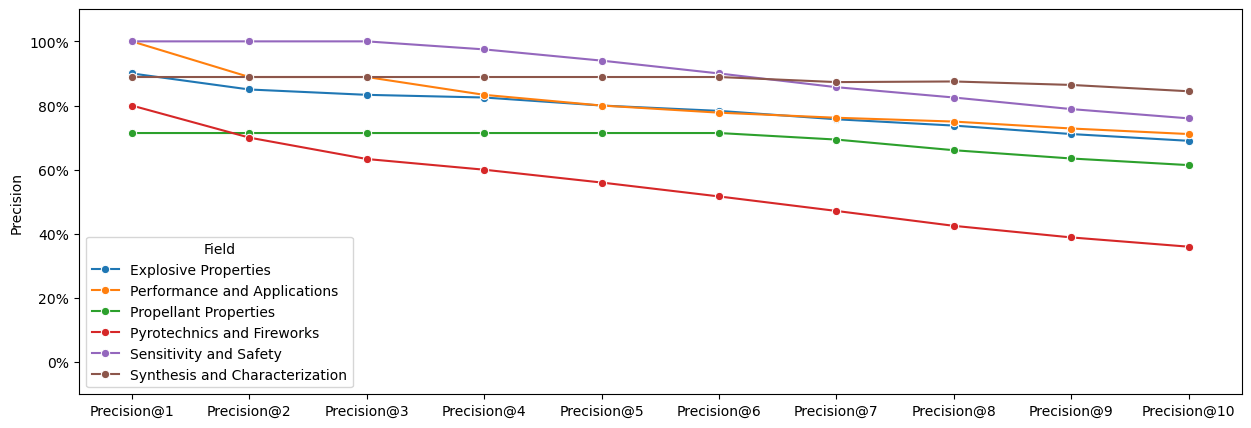

In [61]:
plt.figure(figsize=(15,5))
sns.lineplot(data=df_rag_mod, x='variable', y='value', hue='Field', marker='o')
plt.xlabel('')
plt.ylabel('Precision')
plt.ylim(-0.1,1.1)
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
plt.show()

In [62]:
df_rag_all = df_rag_mod[['variable','value']].groupby('variable').mean()

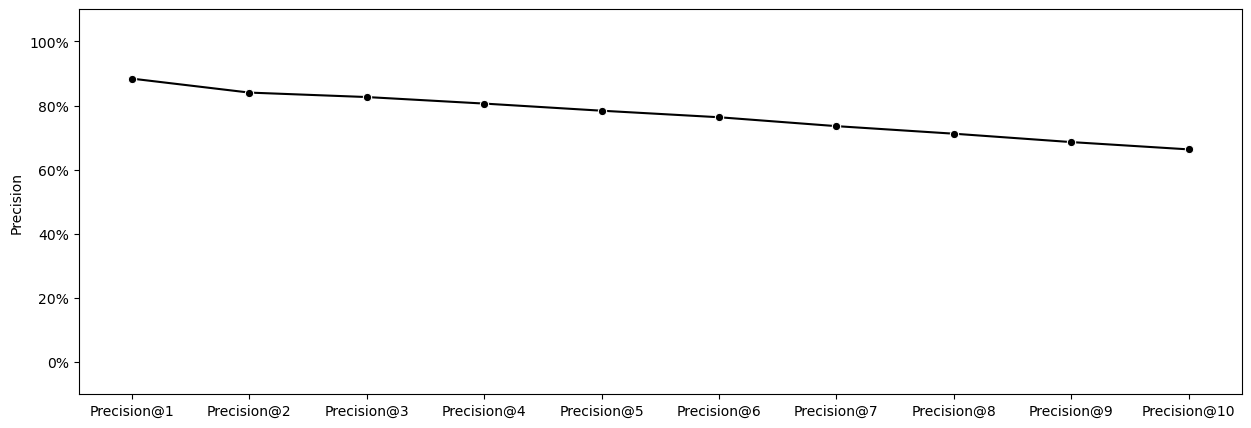

In [63]:
plt.figure(figsize=(15,5))
sns.lineplot(data=df_rag_all.sort_values('value', ascending=False), x='variable', y='value', marker='o', color='k')
plt.xlabel('')
plt.ylabel('Precision')
plt.ylim(-0.1,1.1)
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
plt.show()

## Recall@k

$R@k=\frac{1}{|\mathcal{R}|}\sum_{i=1}^k rel_i$

In [64]:
df_rag = pd.read_csv('Recall_at_k.csv')

In [65]:
df_rag = df_rag[df_rag['Error'].isna()]

In [66]:
df_rag_mod = df_rag.filter(regex='Recall|Field').groupby(by='Field', as_index=False).mean()

In [67]:
df_rag_mod = df_rag_mod.melt(id_vars='Field')

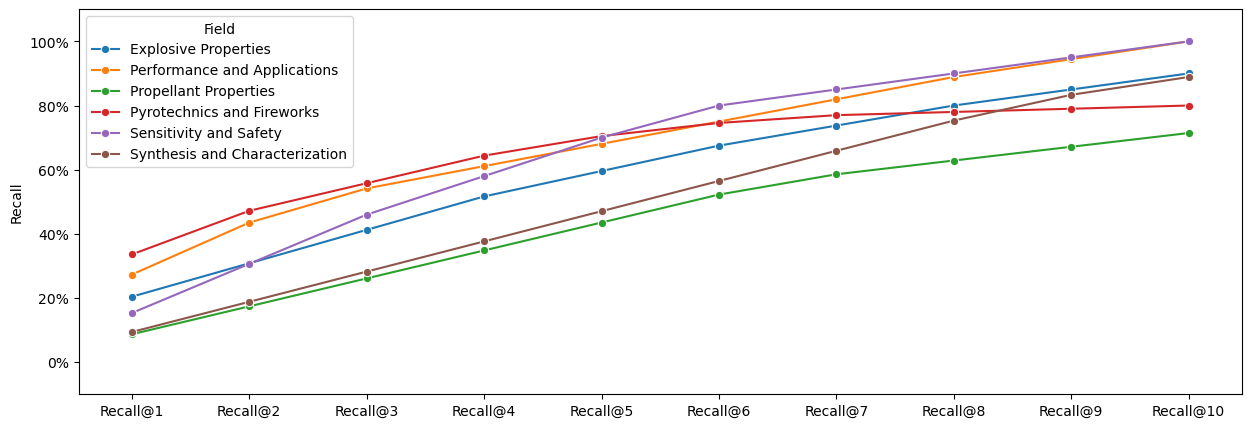

In [69]:
plt.figure(figsize=(15,5))
sns.lineplot(data=df_rag_mod, x='variable', y='value', hue='Field', marker='o')
plt.xlabel('')
plt.ylabel('Recall')
plt.ylim(-0.1,1.1)
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
plt.show()

In [70]:
df_rag_all = df_rag_mod[['variable','value']].groupby('variable').mean()

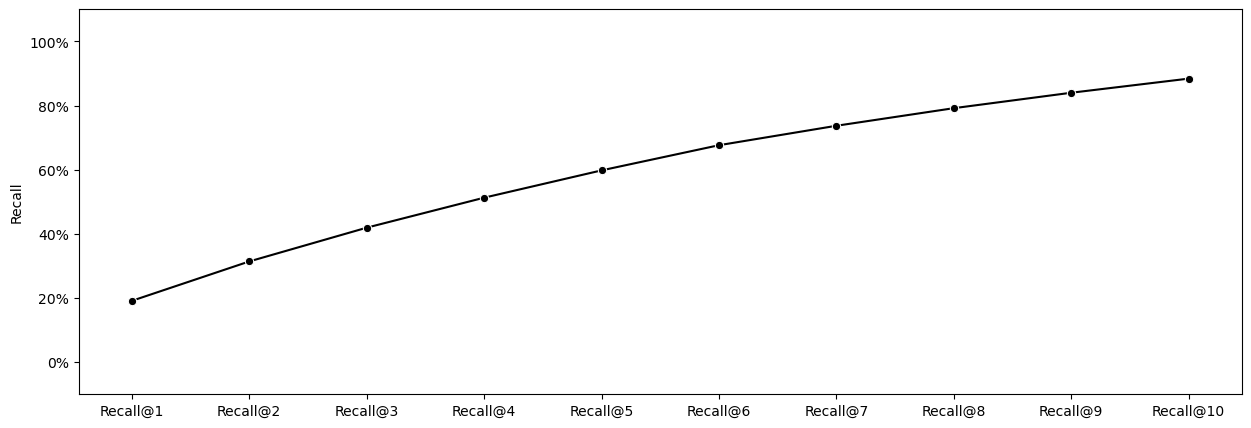

In [71]:
plt.figure(figsize=(15,5))
sns.lineplot(data=df_rag_all.sort_values('value'), x='variable', y='value', marker='o', color='k')
plt.xlabel('')
plt.ylabel('Recall')
plt.ylim(-0.1,1.1)
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
plt.show()